# Stock price prediction using simple ML techniques 

In [59]:
! pip install numpy pandas matplotlib scikit-learn pandas_ta seaborn

## Import basic libraries and check the dataset structure

In [1]:
import pandas as pd
import numpy as np
import pandas_ta as ta
import matplotlib.pyplot as plt
import seaborn as sns

## Load dataset

Do correct typing of all values and calculate the minimum and maximum values in the `Date` column to identify the span of the dataset.

In [2]:
raw_data = pd.read_csv('NVDA.csv', parse_dates=['Date'])
raw_data['Close'] = raw_data['Close'].astype(float)
raw_data['High'] = raw_data['High'].astype(float)
raw_data['Low'] = raw_data['Low'].astype(float)
raw_data['Volume'] = raw_data['Volume'].astype(float)

print("Date range:", raw_data['Date'].min().date(), "->", raw_data['Date'].max().date())
print("Raw shape:", raw_data.shape)
raw_data.head()

Date range: 1999-01-22 -> 2025-02-14
Raw shape: (6558, 7)


,Date,Adj Close,Close,High,Low,Open,Volume
0,1999-01-22,0.037615,0.041016,0.048828,0.038802,0.043750,2.714688e+09
1,1999-01-25,0.041556,0.045313,0.045833,0.041016,0.044271,5.104800e+08
2,1999-01-26,0.038331,0.041797,0.046745,0.041146,0.045833,3.432000e+08
3,1999-01-27,0.038212,0.041667,0.042969,0.039583,0.041927,2.443680e+08
4,1999-01-28,0.038092,0.041536,0.041927,0.041276,0.041667,2.275200e+08


## Simple Technical Indicator

Simply compute technical indicator using pandas_ta

In [3]:
df = raw_data.copy()

df['SMA_20'] = ta.sma(df['Close'], length=20)
df['SMA_50'] = ta.sma(df['Close'], length=50)
df['EMA_12'] = ta.ema(df['Close'], length=12)
df['EMA_26'] = ta.ema(df['Close'], length=26)
df['RSI']    = ta.rsi(df['Close'], length=14)

macd = ta.macd(df['Close'], fast=12, slow=26, signal=9)
df['MACD'] = macd['MACD_12_26_9']
df['MACD_Signal'] = macd['MACDs_12_26_9']

bb = ta.bbands(df['Close'], length=20)
df['BB_Lower'] = bb.iloc[:, 0]
df['BB_Mid'] = bb.iloc[:, 1]
df['BB_Upper'] = bb.iloc[:, 2]

df['ATR'] = ta.atr(high=df['High'], low=df['Low'], close=df['Close'], length=14)

stoch = ta.stoch(high=df['High'], low=df['Low'], close=df['Close'], k=14, d=3)
df['Stoch_K'] = stoch['STOCHk_14_3_3']
df['Stoch_D'] = stoch['STOCHd_14_3_3']

df['OBV'] = ta.obv(df['Close'], df['Volume'])
df['CCI'] = ta.cci(high=df['High'], low=df['Low'], close=df['Close'], length=20)
df['ROC'] = ta.roc(df['Close'], length=12)

df['ADX'] = ta.adx(high=df['High'], low=df['Low'], close=df['Close'], length=14)['ADX_14']
df['Williams_R'] = ta.willr(high=df['High'], low=df['Low'], close=df['Close'], length=14)

df['BB_Width'] = (df['BB_Upper'] - df['BB_Lower']) / df['BB_Mid']  # Bollinger bandwidth
df['ATR_Pct'] = df['ATR'] / df['Close']  # ATR as % of price

df['Volume_Ratio'] = df['Volume'] / df['Volume'].rolling(20).mean()  # vs 20-day avg
df['MFI'] = ta.mfi(high=df['High'], low=df['Low'],
                             close=df['Close'], volume=df['Volume'], length=14)

df['SMA20_Dist'] = (df['Close'] - df['SMA_20']) / df['SMA_20']  # % distance from SMA20
df['HL_Range'] = (df['High'] - df['Low']) / df['Close']  # intraday range %

df['RSI_lag1'] = df['RSI'].shift(1)
df['ROC_lag1'] = df['ROC'].shift(1)
df['MACD_lag1'] = df['MACD'].shift(1)

df['RSI_roll5_mean'] = df['RSI'].rolling(5).mean()
df['ROC_roll5_mean'] = df['ROC'].rolling(5).mean()
df['ROC_roll5_std'] = df['ROC'].rolling(5).std()

print("Shape after indicators:", df.shape)
df[['Date','Close','SMA_20','EMA_12','RSI','MACD','ATR','OBV', 'ROC']].tail(5)

Shape after indicators: (6558, 37)


,Date,Close,SMA_20,EMA_12,RSI,MACD,ATR,OBV,ROC
6553,2025-02-10,133.570007,130.915501,128.353280,51.981874,-2.826277,6.859995,1.587528e+11,-9.271834
6554,2025-02-11,132.800003,130.894001,129.037391,51.280517,-2.262199,6.617138,1.585739e+11,-6.885424
6555,2025-02-12,131.139999,130.863002,129.360869,49.722957,-1.926899,6.410199,1.584136e+11,10.741430
6556,2025-02-13,135.289993,130.815501,130.273042,53.523526,-1.311187,6.335185,1.586110e+11,4.884090
6557,2025-02-14,138.850006,131.079501,131.592575,56.557309,-0.529860,6.165530,1.588059e+11,12.247380


## Visualise indicators
Yea... Well... Visualisation...

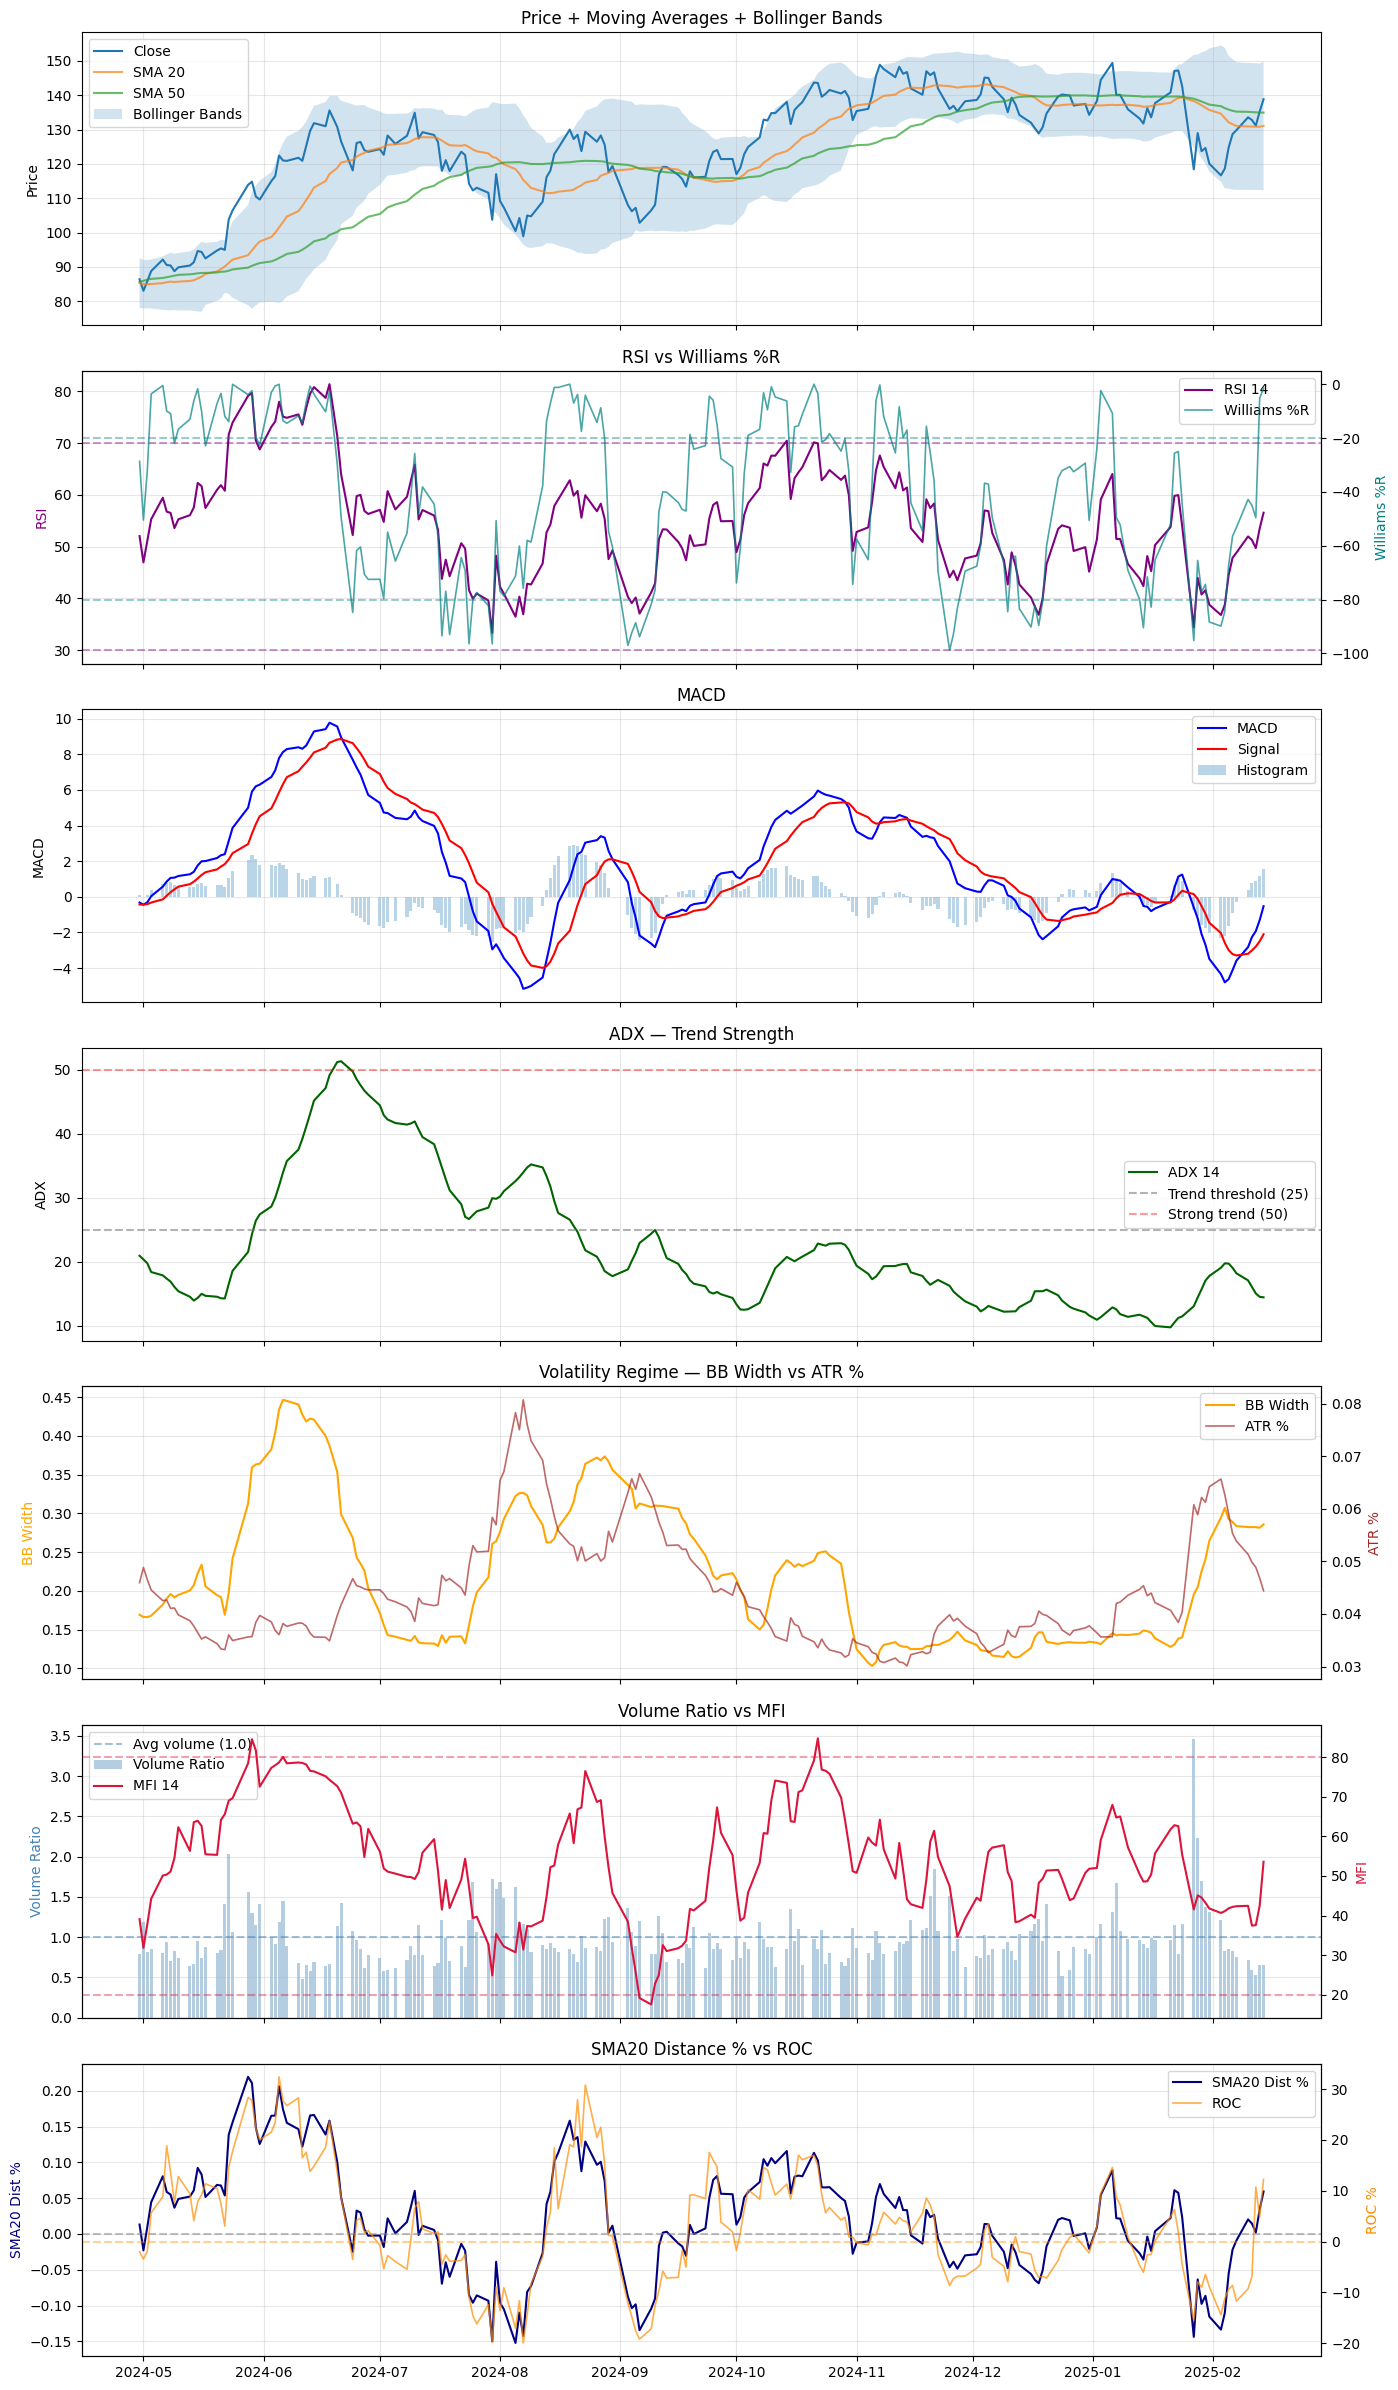

In [4]:
plot_data = df.tail(200)
fig, axes = plt.subplots(7, 1, figsize=(14, 24), sharex=True)

axes[0].plot(plot_data['Date'], plot_data['Close'], label='Close', linewidth=1.5)
axes[0].plot(plot_data['Date'], plot_data['SMA_20'], label='SMA 20', alpha=0.7)
axes[0].plot(plot_data['Date'], plot_data['SMA_50'], label='SMA 50', alpha=0.7)
axes[0].fill_between(plot_data['Date'], plot_data['BB_Upper'], plot_data['BB_Lower'], alpha=0.2, label='Bollinger Bands')
axes[0].set_ylabel('Price')
axes[0].set_title('Price + Moving Averages + Bollinger Bands')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

ax0b = axes[1].twinx()
axes[1].plot(plot_data['Date'], plot_data['RSI'], color='purple', label='RSI 14', linewidth=1.5)
axes[1].axhline(70, color='purple', linestyle='--', alpha=0.4)
axes[1].axhline(30, color='purple', linestyle='--', alpha=0.4)
axes[1].set_ylabel('RSI', color='purple')
axes[1].set_title('RSI vs Williams %R')
ax0b.plot(plot_data['Date'], plot_data['Williams_R'], color='teal', label='Williams %R', alpha=0.7, linewidth=1.2)
ax0b.axhline(-20, color='teal', linestyle='--', alpha=0.4)
ax0b.axhline(-80, color='teal', linestyle='--', alpha=0.4)
ax0b.set_ylabel('Williams %R', color='teal')
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax0b.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2)
axes[1].grid(True, alpha=0.3)

axes[2].plot(plot_data['Date'], plot_data['MACD'], label='MACD', color='blue')
axes[2].plot(plot_data['Date'], plot_data['MACD_Signal'], label='Signal', color='red')
axes[2].bar(plot_data['Date'], plot_data['MACD'] - plot_data['MACD_Signal'], alpha=0.3, label='Histogram')
axes[2].set_ylabel('MACD')
axes[2].set_title('MACD')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

axes[3].plot(plot_data['Date'], plot_data['ADX'], color='darkgreen', label='ADX 14', linewidth=1.5)
axes[3].axhline(25, color='gray', linestyle='--', alpha=0.6, label='Trend threshold (25)')
axes[3].axhline(50, color='red',  linestyle='--', alpha=0.4, label='Strong trend (50)')
axes[3].set_ylabel('ADX')
axes[3].set_title('ADX — Trend Strength')
axes[3].legend(); axes[3].grid(True, alpha=0.3)

ax4b = axes[4].twinx()
axes[4].plot(plot_data['Date'], plot_data['BB_Width'], color='orange', label='BB Width', linewidth=1.5)
axes[4].set_ylabel('BB Width', color='orange')
axes[4].set_title('Volatility Regime — BB Width vs ATR %')
ax4b.plot(plot_data['Date'], plot_data['ATR_Pct'], color='brown', label='ATR %', alpha=0.7, linewidth=1.2)
ax4b.set_ylabel('ATR %', color='brown')
lines1, labels1 = axes[4].get_legend_handles_labels()
lines2, labels2 = ax4b.get_legend_handles_labels()
axes[4].legend(lines1 + lines2, labels1 + labels2)
axes[4].grid(True, alpha=0.3)

ax5b = axes[5].twinx()
axes[5].bar(plot_data['Date'], plot_data['Volume_Ratio'], alpha=0.4, color='steelblue', label='Volume Ratio')
axes[5].axhline(1.0, color='steelblue', linestyle='--', alpha=0.5, label='Avg volume (1.0)')
axes[5].set_ylabel('Volume Ratio', color='steelblue')
axes[5].set_title('Volume Ratio vs MFI')
ax5b.plot(plot_data['Date'], plot_data['MFI'], color='crimson', label='MFI 14', linewidth=1.5)
ax5b.axhline(80, color='crimson', linestyle='--', alpha=0.4)
ax5b.axhline(20, color='crimson', linestyle='--', alpha=0.4)
ax5b.set_ylabel('MFI', color='crimson')
lines1, labels1 = axes[5].get_legend_handles_labels()
lines2, labels2 = ax5b.get_legend_handles_labels()
axes[5].legend(lines1 + lines2, labels1 + labels2)
axes[5].grid(True, alpha=0.3)

ax6b = axes[6].twinx()
axes[6].plot(plot_data['Date'], plot_data['SMA20_Dist'], color='navy', label='SMA20 Dist %', linewidth=1.5)
axes[6].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[6].set_ylabel('SMA20 Dist %', color='navy')
axes[6].set_title('SMA20 Distance % vs ROC')
ax6b.plot(plot_data['Date'], plot_data['ROC'], color='darkorange', label='ROC', alpha=0.7, linewidth=1.2)
ax6b.axhline(0, color='darkorange', linestyle='--', alpha=0.4)
ax6b.set_ylabel('ROC %', color='darkorange')
lines1, labels1 = axes[6].get_legend_handles_labels()
lines2, labels2 = ax6b.get_legend_handles_labels()
axes[6].legend(lines1 + lines2, labels1 + labels2)
axes[6].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Target Engineering

We define a binary classification target based on future price movement over a 30-day horizon.

- Label = 1 if the **30-day future return of Close price is positive**
- Label = 0 otherwise

In [6]:
print(f"NaNs before cleaning: {df.isna().sum().sum()}")
df = df.dropna()
df = df.sort_values('Date').reset_index(drop=True)
print(f"NaNs after cleaning:  {df.isna().sum().sum()}")

# TARGET (REAL PRICE-BASED DIRECTION)
df['Future_Close'] = df['Close'].shift(-30)

# future return (more stable than raw difference or ROC)
df['Future_Return'] = (df['Future_Close'] - df['Close']) / df['Close']

# direction target (1 = up, 0 = down or flat)
df['Price_Direction_30d'] = (df['Future_Return'] > 0).astype(int)

# cleanup
df.dropna(subset=['Future_Close'], inplace=True)
df.drop(columns=['Future_Close'], inplace=True)
df.reset_index(drop=True, inplace=True)

print("Shape after target engineering:", df.shape)

print("\nClass distribution:")
print(df['Price_Direction_30d'].value_counts(normalize=True).round(3))

NaNs before cleaning: 0
NaNs after cleaning:  0
Shape after target engineering: (6449, 39)

Class distribution:
Price_Direction_30d
1    0.619
0    0.381
Name: proportion, dtype: float64


## Class distribution plot

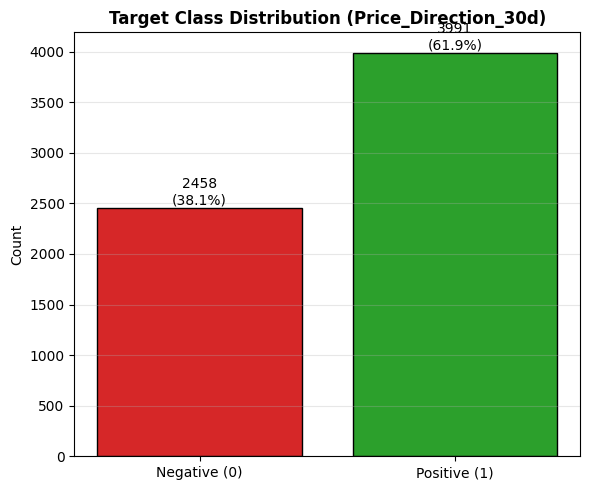

In [8]:
class_dist = df['Price_Direction_30d'].value_counts().sort_index()
class_pct = df['Price_Direction_30d'].value_counts(normalize=True).sort_index() * 100
labels = ['Negative (0)', 'Positive (1)']

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(labels, [class_dist[0], class_dist[1]], color=['#d62728', '#2ca02c'], edgecolor='black')

for bar, lbl in zip(bars, [0, 1]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{class_dist[lbl]}\n({class_pct[lbl]:.1f}%)", ha='center', va='bottom')

ax.set_title('Target Class Distribution (Price_Direction_30d)', fontweight='bold')
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Yearly class distribution

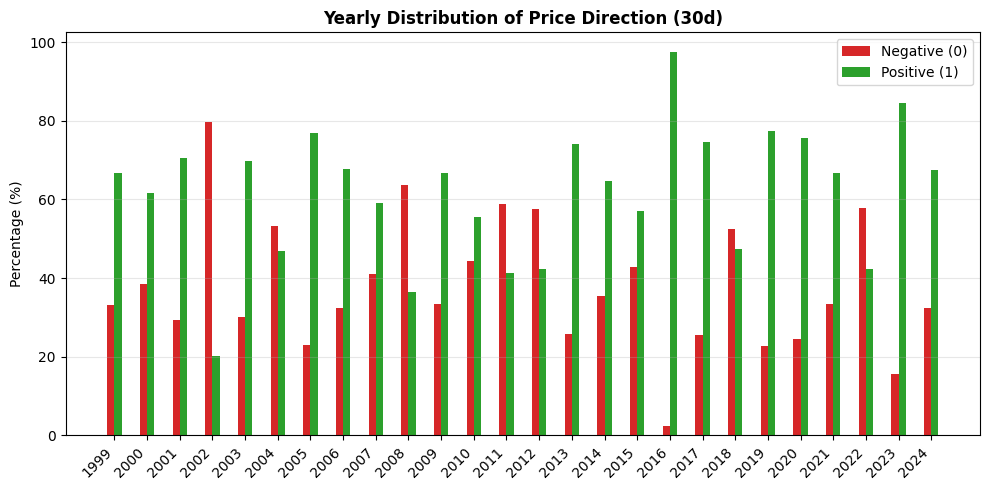

In [9]:
df['Year'] = df['Date'].dt.year
yearly_pct = pd.crosstab(df['Year'], df['Price_Direction_30d'], normalize='index') * 100
yearly_pct = yearly_pct.reindex(columns=[0, 1], fill_value=0)

spacing = 1.6
x     = [i * spacing for i in range(len(yearly_pct))]
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([i - width/2 for i in x], yearly_pct[0], width, label='Negative (0)', color='#d62728')
ax.bar([i + width/2 for i in x], yearly_pct[1], width, label='Positive (1)',  color='#2ca02c')
ax.set_xticks(x)
ax.set_xticklabels(yearly_pct.index.astype(int), rotation=45, ha='right')
ax.set_ylabel('Percentage (%)')
ax.set_title('Yearly Distribution of Price Direction (30d)', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

df.drop(columns=['Year'], inplace=True)

## ROC descriptive statistics

In [10]:
roc = df['ROC'].dropna()
print("=" * 30)
print("ROC (12-period) DESCRIPTIVE STATISTICS")
print("=" * 30)
stats = {
    'Mean': roc.mean(), 'Median': roc.median(), 'Std Dev': roc.std(),
    'Skewness': roc.skew(), 'Kurtosis': roc.kurtosis(),
    'Min': roc.min(), 'Max': roc.max(),
    'IQR': roc.quantile(0.75) - roc.quantile(0.25)
}
for k, v in stats.items():
    print(f"  {k:<12} {v:>10.4f}")

ROC (12-period) DESCRIPTIVE STATISTICS
  Mean             2.3579
  Median           1.8594
  Std Dev         13.1483
  Skewness         0.6975
  Kurtosis         4.5599
  Min            -54.7128
  Max            128.7352
  IQR             13.6748


## Full correlation matrix (all computed features)

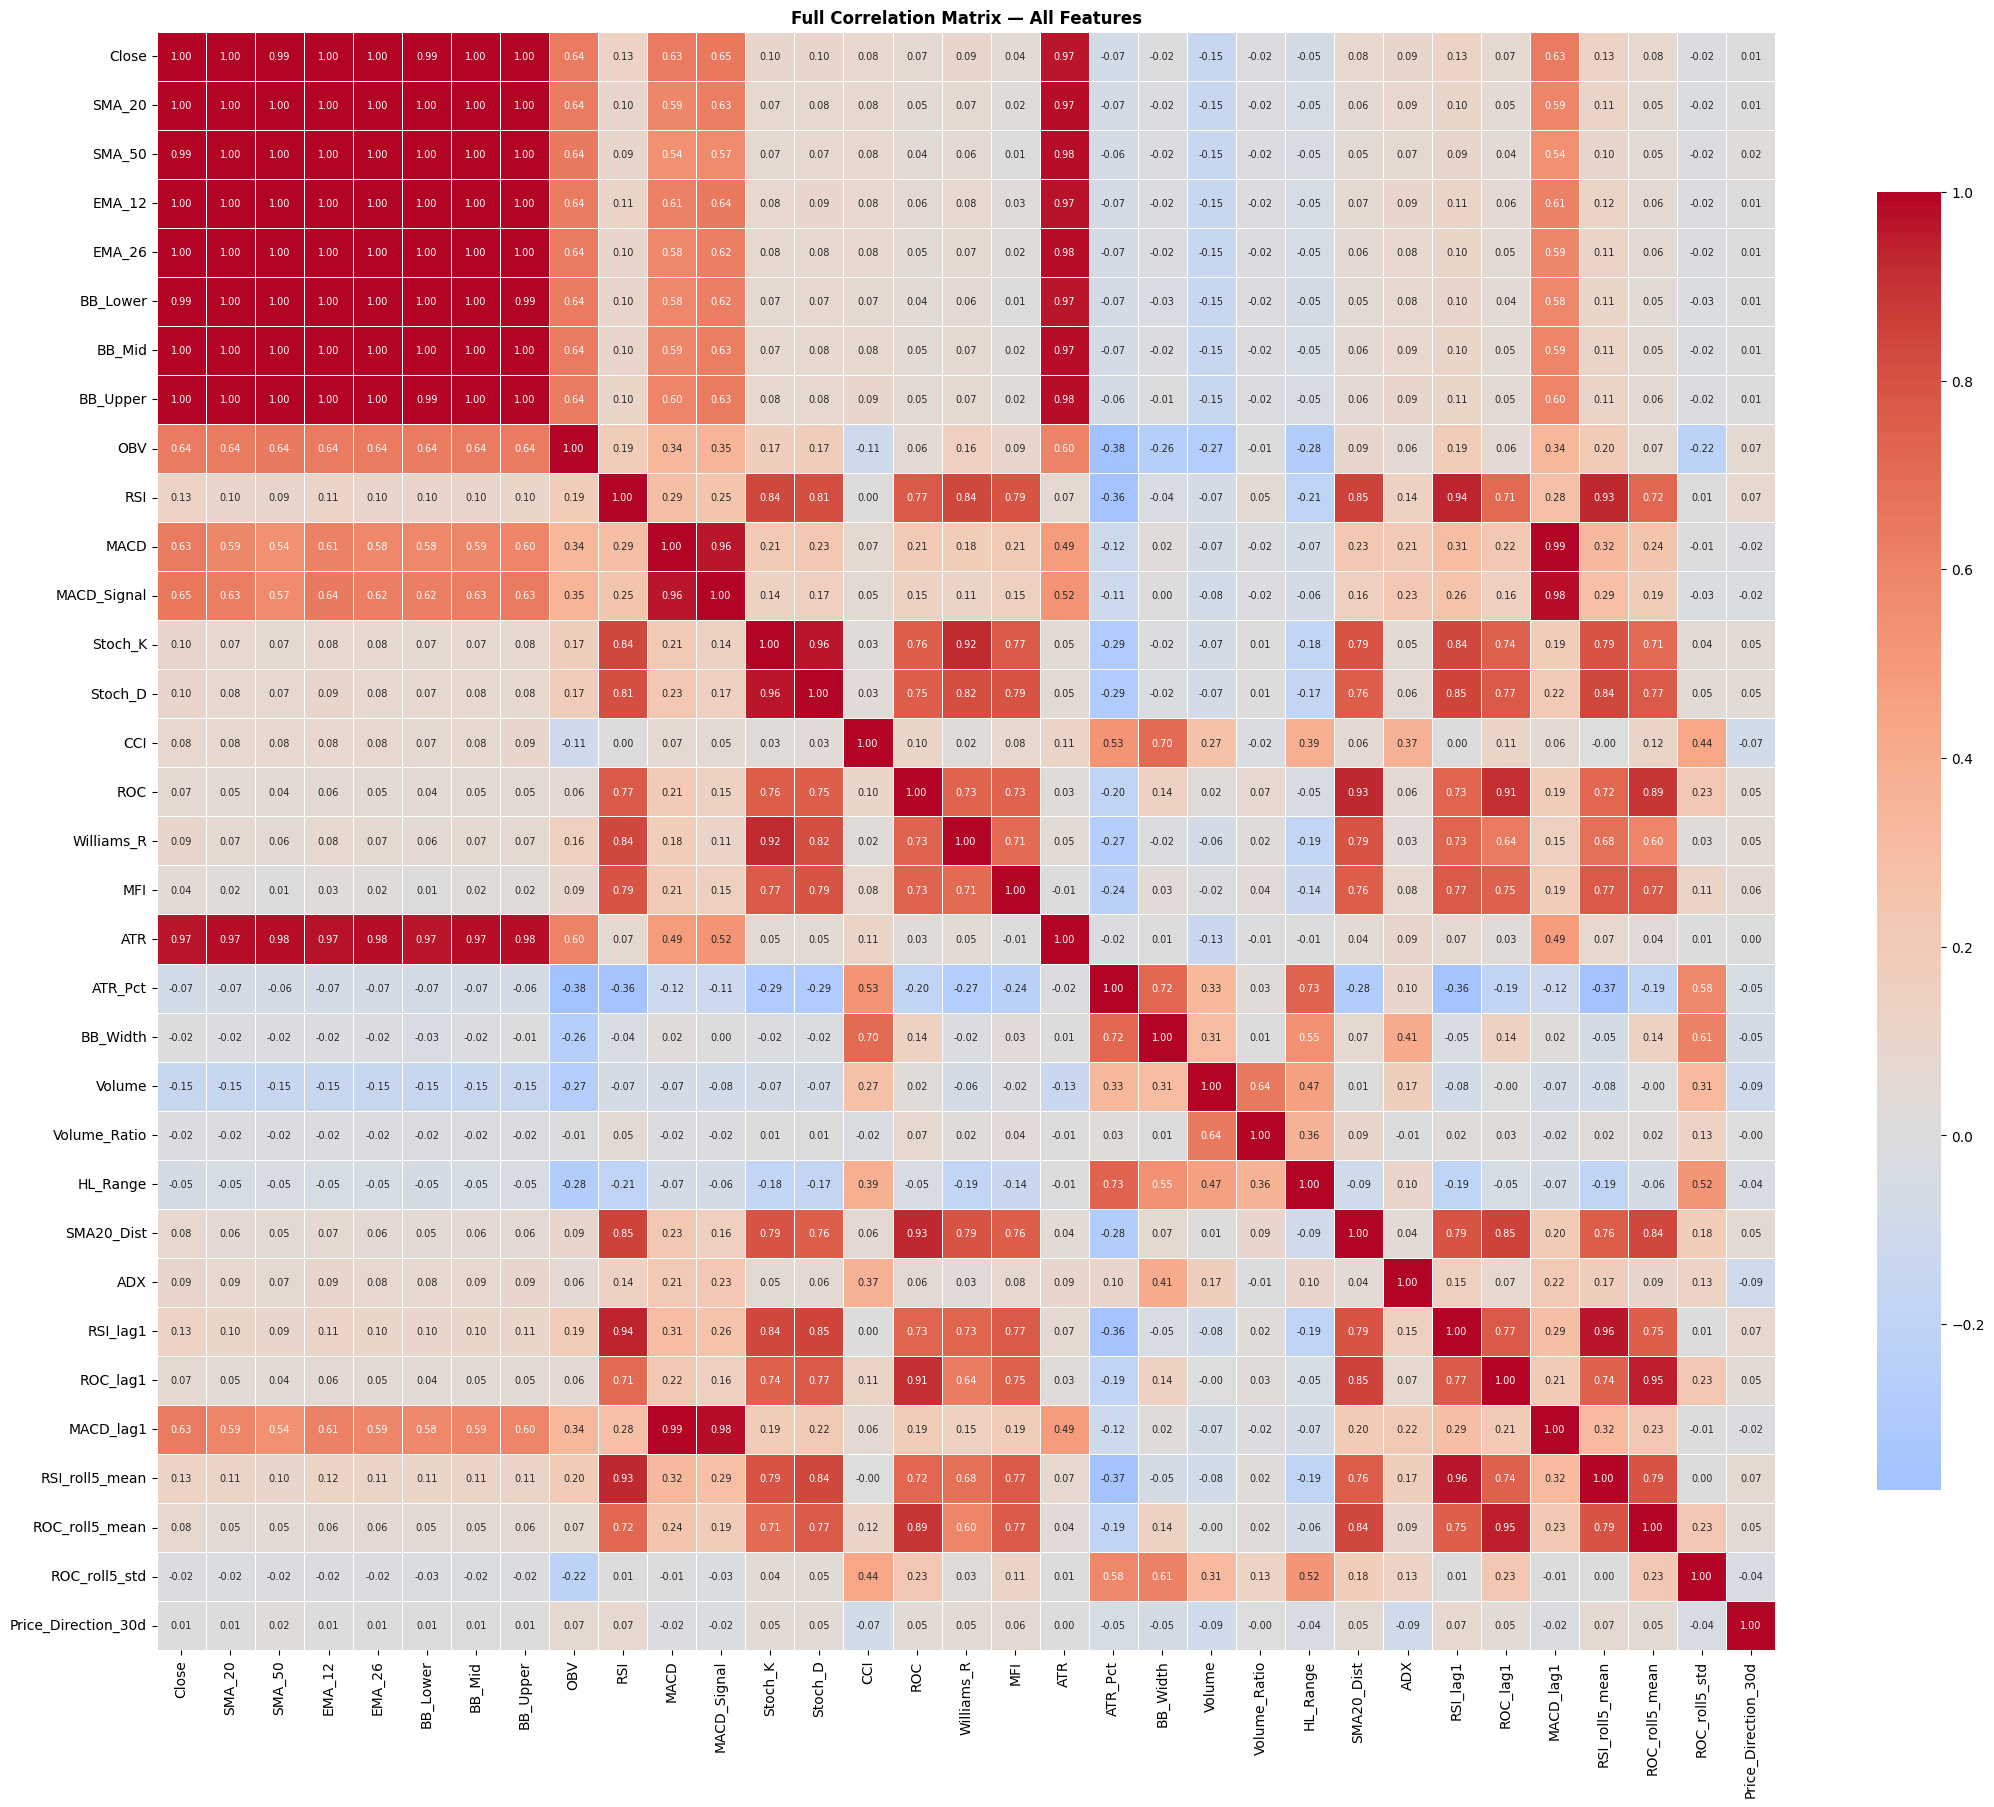

In [11]:
all_features = [
    # Price-level (expected to be multicollinear — shown here as evidence)
    'Close', 'SMA_20', 'SMA_50', 'EMA_12', 'EMA_26',
    'BB_Lower', 'BB_Mid', 'BB_Upper', 'OBV',
    # Oscillators / momentum
    'RSI', 'MACD', 'MACD_Signal', 'Stoch_K', 'Stoch_D',
    'CCI', 'ROC', 'Williams_R', 'MFI',
    # Volatility
    'ATR', 'ATR_Pct', 'BB_Width',
    # Volume / structure
    'Volume', 'Volume_Ratio', 'HL_Range', 'SMA20_Dist',
    # Trend strength
    'ADX',
    # Lagged
    'RSI_lag1', 'ROC_lag1', 'MACD_lag1',
    # Rolling
    'RSI_roll5_mean', 'ROC_roll5_mean', 'ROC_roll5_std',
    # Target
    'Price_Direction_30d'
]

corr_full = df[all_features].corr()

plt.figure(figsize=(22, 18))
sns.heatmap(corr_full, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            annot_kws={"size": 7})
plt.title('Full Correlation Matrix — All Features', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

## Feature selection: drop multicollinear features

**Dropped — price-level / non-stationary:**
- `Close`, `SMA_20`, `SMA_50`, `EMA_12`, `EMA_26` — raw price values, |r| > 0.99 with each other
- `BB_Mid`, `BB_Upper`, `BB_Lower` — BB_Mid is identical to SMA_20 by construction; upper/lower are SMA_20 ± 2σ
- `OBV` — cumulative sum that grows monotonically with price trend; non-stationary
- `Volume` — raw volume is non-stationary; replaced by normalised `Volume_Ratio`

**Dropped — redundant derived features:**
- `MACD` — highly correlated with `MACD_Signal` (signal is a smoothed MACD); keep `MACD_Signal`
- `Stoch_D` — 3-period SMA of `Stoch_K`, near-duplicate (|r| > 0.95); keep `Stoch_K`
- `ATR` — replaced by `ATR_Pct` (ATR / Close), which removes price-scale dependency
- `Williams_R` — bounded oscillator measuring same overbought/oversold dynamic as `Stoch_K` (|r| > 0.85); keep `Stoch_K`
- `RSI_roll5_mean` — highly correlated with `RSI` and `RSI_lag1`; adds little beyond them
- `MACD_lag1` — correlated with both `MACD_Signal` and `ROC_lag1`

**Features kept — independent, stationary, bounded/normalised signals:**
| Feature | Type | Rationale |
|---|---|---|
| `RSI` | Momentum oscillator | Bounded 0–100, captures overbought/oversold |
| `MACD_Signal` | Trend momentum | Smoothed crossover signal, lower noise than raw MACD |
| `Stoch_K` | Momentum oscillator | Price position within recent range |
| `CCI` | Mean reversion | Deviation from average price, bounded in practice |
| `ROC` | Rate of change | % momentum, directly related to target construction |
| `ADX` | Trend strength | Measures how strongly price is trending, independent of direction |
| `MFI` | Volume-weighted momentum | RSI incorporating volume — adds information RSI alone misses |
| `ATR_Pct` | Normalised volatility | ATR as % of Close — stationary, no price-scale collinearity |
| `BB_Width` | Volatility regime | Band expansion/contraction, independent of price level |
| `Volume_Ratio` | Normalised volume | Volume vs 20-day average — stationary, confirms moves |
| `SMA20_Dist` | Price structure | % distance from SMA20 — mean reversion signal, stationary |
| `HL_Range` | Intraday volatility | (High−Low)/Close — daily range as % of price |
| `RSI_lag1` | Lagged momentum | Yesterday's RSI — gives RF implicit time context |
| `ROC_lag1` | Lagged momentum | Yesterday's ROC — sequential momentum context |
| `ROC_roll5_mean` | Rolling momentum | 5-day smoothed ROC — reduces daily noise |
| `ROC_roll5_std` | Momentum volatility | Consistency of recent momentum |

In [12]:
FEATURES = [
    'MACD_Signal', 'Stoch_K', 'CCI',
    'ADX', 'MFI', 'ATR_Pct', 'BB_Width',
    'Volume_Ratio', 'SMA20_Dist', 'HL_Range',
    'RSI_lag1', 'ROC_roll5_mean', 'ROC_roll5_std'
]
TARGET = 'Price_Direction_30d'

print("Selected features:", FEATURES)
print(f"\nCorrelation with target ({TARGET}):")
corr_selected = df[FEATURES + [TARGET]].corr()
print(corr_selected[TARGET].drop(TARGET).sort_values(ascending=False).to_string())

Selected features: ['MACD_Signal', 'Stoch_K', 'CCI', 'ADX', 'MFI', 'ATR_Pct', 'BB_Width', 'Volume_Ratio', 'SMA20_Dist', 'HL_Range', 'RSI_lag1', 'ROC_roll5_mean', 'ROC_roll5_std']

Correlation with target (Price_Direction_30d):
RSI_lag1          0.070636
MFI               0.056067
SMA20_Dist        0.053590
ROC_roll5_mean    0.048889
Stoch_K           0.048238
Volume_Ratio     -0.000922
MACD_Signal      -0.023945
ROC_roll5_std    -0.037277
HL_Range         -0.039444
ATR_Pct          -0.048057
BB_Width         -0.054424
CCI              -0.074823
ADX              -0.092029


## Correlation with new features

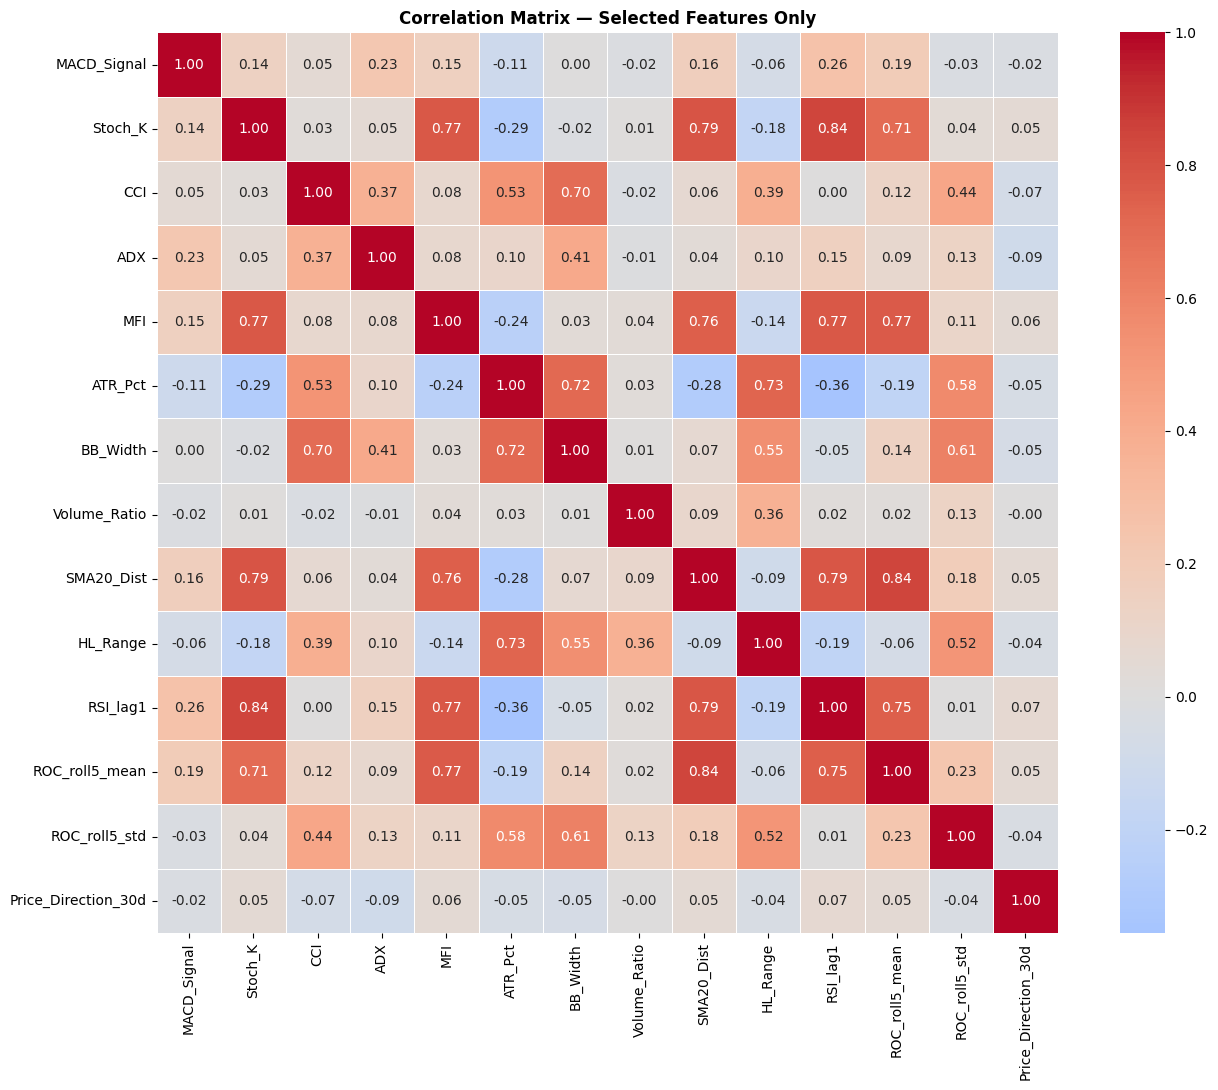

In [13]:
plt.figure(figsize=(14, 11))
sns.heatmap(corr_selected, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix — Selected Features Only', fontweight='bold')
plt.tight_layout()
plt.show()

## Mutual Information (non-linear feature relevance)

Mutual Information Scores (higher = more relevant, captures non-linear):
       Feature  MI_Score
   MACD_Signal  0.028577
    SMA20_Dist  0.017920
       ATR_Pct  0.016291
      BB_Width  0.013590
      RSI_lag1  0.012579
ROC_roll5_mean  0.010806
      HL_Range  0.007651
           CCI  0.003788
 ROC_roll5_std  0.001159
           MFI  0.000976
       Stoch_K  0.000000
           ADX  0.000000
  Volume_Ratio  0.000000


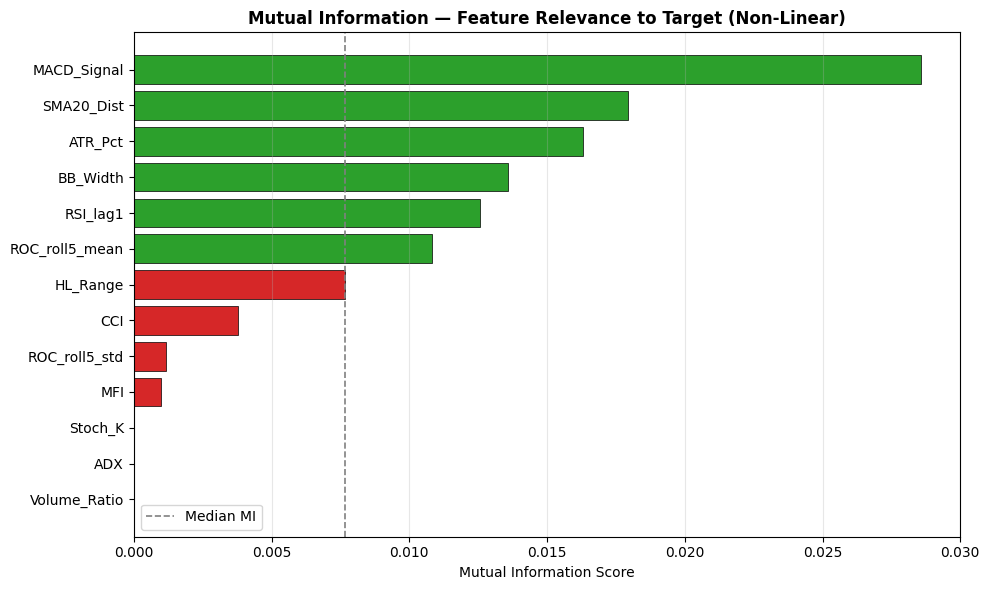

In [14]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(df[FEATURES], df[TARGET], random_state=42)

mi_df = pd.DataFrame({
    'Feature':  FEATURES,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False).reset_index(drop=True)

print("Mutual Information Scores (higher = more relevant, captures non-linear):")
print(mi_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ca02c' if s > mi_df['MI_Score'].median() else '#d62728' for s in mi_df['MI_Score']]
ax.barh(mi_df['Feature'], mi_df['MI_Score'], color=colors, edgecolor='black', linewidth=0.5)
ax.invert_yaxis()
ax.axvline(mi_df['MI_Score'].median(), color='gray', linestyle='--', linewidth=1.2, label='Median MI')
ax.set_xlabel('Mutual Information Score')
ax.set_title('Mutual Information — Feature Relevance to Target (Non-Linear)', fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

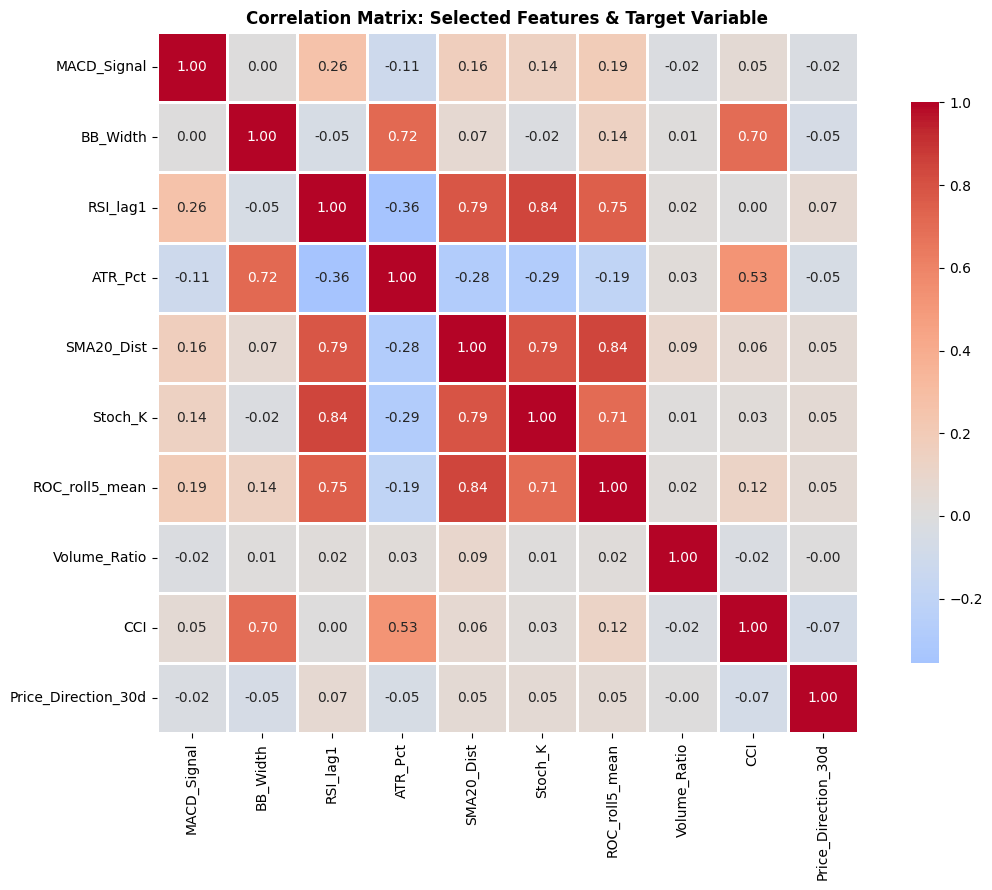

In [15]:
# Drop zero-MI features: MFI, ADX, HL_Range, ROC_roll5_std
FEATURES = [
    'MACD_Signal',   # strongest non-linear signal (MI=0.025)
    'BB_Width',      # volatility regime — how wide the bands are
    'RSI_lag1',      # lagged momentum — yesterday's RSI
    'ATR_Pct',       # normalised volatility — ATR as % of price
    'SMA20_Dist',    # % distance from SMA20 — mean reversion signal
    'Stoch_K',       # price position within recent range
    'ROC_roll5_mean',# 5-day smoothed ROC
    'Volume_Ratio',  # normalised volume vs 20-day average
    'CCI',           # deviation from average price
]
TARGET = 'Price_Direction_30d'

correlation_matrix = df[FEATURES + [TARGET]].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: Selected Features & Target Variable', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

## Save new dataset

In [16]:
final_df = df[['Date'] + FEATURES + [TARGET]].copy()
final_df.to_csv('model_data.csv', index=False)

print(f"Saved model_data.csv — shape: {final_df.shape}")
print(f"Columns: {final_df.columns.tolist()}")
print(f"\nClass balance:\n{final_df[TARGET].value_counts(normalize=True).round(3)}")

Saved model_data.csv — shape: (6449, 11)
Columns: ['Date', 'MACD_Signal', 'BB_Width', 'RSI_lag1', 'ATR_Pct', 'SMA20_Dist', 'Stoch_K', 'ROC_roll5_mean', 'Volume_Ratio', 'CCI', 'Price_Direction_30d']

Class balance:
Price_Direction_30d
1    0.619
0    0.381
Name: proportion, dtype: float64
